This application solves the Traveling Salesman Problem (TSP) with the Simulated Annealing (SA) algorithm on a list of cities in Palestine. TSP is the shortest overall length tour that visits each city once and comes back to the starting point. Simulated Annealing avoids trapping in local minima by taking worse solutions with some probability, primarily at the start, that decreases as the system gets cold. The algorithm initializes a random tour of the cities of the Palestinian cities of Bethlehem, Gaza, Ramallah, and Jenin and then searches continuously for the optimal routes. The code includes visualizations for the starting route and optimized route using matplotlib such that users have an idea how the route optimizes with the passage of time

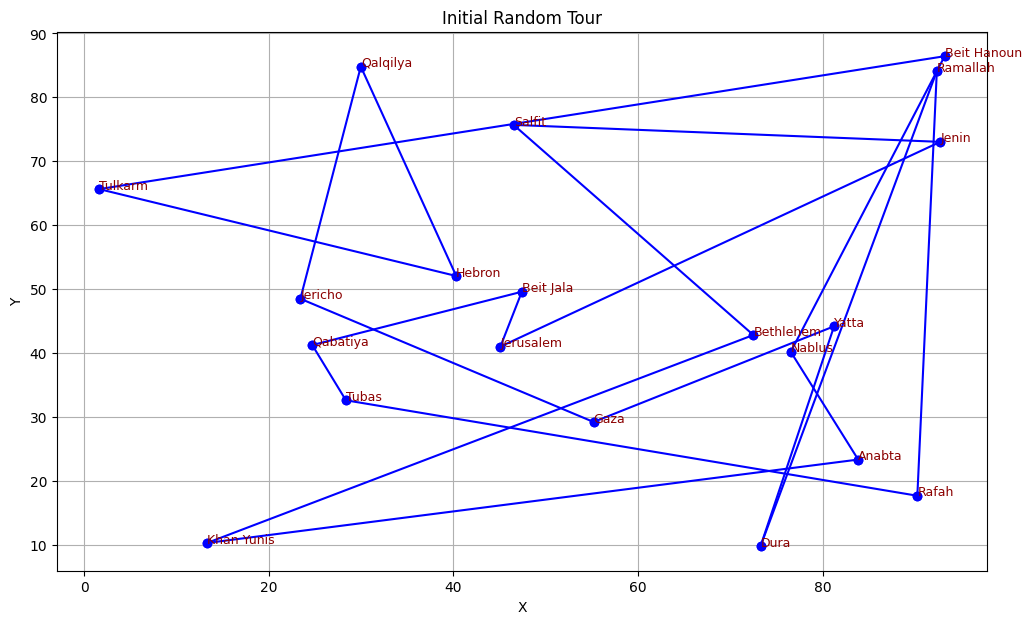

 Best total distance found: 425.90


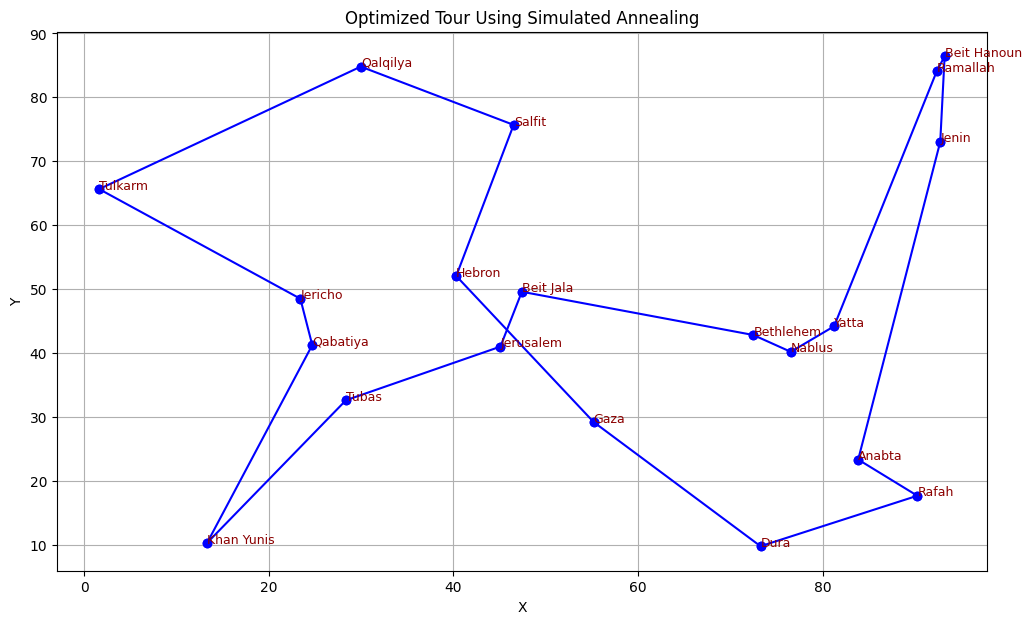

In [13]:
import math                     
import random                  
import matplotlib.pyplot as plt 
import numpy as np            

# ---------------------- Step 1: Palestinian Cities and  Coordinates ----------------------

city_names = [
    "Bethlehem", "Jerusalem", "Nablus", "Hebron", "Ramallah",
    "Tulkarm", "Qalqilya", "Jenin", "Gaza", "Rafah",
    "Khan Yunis", "Jericho", "Beit Jala", "Salfit", "Tubas",
    "Qabatiya", "Yatta", "Dura", "Anabta", "Beit Hanoun"
]

# Assign random (x, y) coordinates to each city 
cities = [tuple(np.random.uniform(0, 100, size=2)) for _ in city_names]

# ---------------------- Step 2:  Functions ----------------------

def euclidean_distance(a, b):
    """Return the straight-line distance between two points (x1, y1) and (x2, y2)."""
    return math.hypot(a[0] - b[0], a[1] - b[1])

def total_distance(tour, cities):
    """Return the total length of the path defined by the tour of cities."""
    return sum(
        euclidean_distance(cities[tour[i]], cities[tour[(i + 1) % len(tour)]])
        for i in range(len(tour))
    )

def generate_neighbor(tour):
    """Return a new tour by swapping two cities (used to explore alternatives)."""
    a, b = random.sample(range(len(tour)), 2)
    neighbor = tour[:]
    neighbor[a], neighbor[b] = neighbor[b], neighbor[a]
    return neighbor

# ---------------------- Step 3: Simulated Annealing Algorithm ----------------------

def simulated_annealing(cities, initial_temp, cooling_rate, stop_temp):
    current_tour = list(range(len(cities)))
    random.shuffle(current_tour)
    current_cost = total_distance(current_tour, cities)

    best_tour = current_tour[:]
    best_cost = current_cost
    temperature = initial_temp

    while temperature > stop_temp:
        new_tour = generate_neighbor(current_tour)
        new_cost = total_distance(new_tour, cities)
        delta = new_cost - current_cost

        # accept the new solution if better or by probability if worse (to escape local minima)
        if delta < 0 or random.random() < math.exp(-delta / temperature):
            current_tour = new_tour
            current_cost = new_cost
            if current_cost < best_cost:
                best_tour = current_tour
                best_cost = current_cost

        temperature *= cooling_rate

    return best_tour, best_cost

# ---------------------- Step 4: Visualization ----------------------

def plot_tour(cities, tour, names, title):
    """Plot the tour path and label each city by name."""
    plt.figure(figsize=(12, 7))
    for i in range(len(tour)):
        x1, y1 = cities[tour[i]]
        x2, y2 = cities[tour[(i + 1) % len(tour)]]
        plt.plot([x1, x2], [y1, y2], 'bo-')  # Draw path between cities
    for i, idx in enumerate(tour):
        x, y = cities[idx]
        plt.text(x, y, names[idx], fontsize=9, color='darkred')
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

# ---------------------- Step 5: Main Execution ----------------------

if __name__ == "__main__":
    initial_temp = 1000
    cooling_rate = 0.995
    stop_temp = 1e-3

    # visualize the starting (random) tour
    initial_tour = list(range(len(cities)))
    random.shuffle(initial_tour)
    plot_tour(cities, initial_tour, city_names, "Initial Random Tour")

    # run Simulated Annealing to find an optimized tour
    best_tour, best_cost = simulated_annealing(cities, initial_temp, cooling_rate, stop_temp)

    print(f" Best total distance found: {best_cost:.2f}")
    plot_tour(cities, best_tour, city_names, "Optimized Tour Using Simulated Annealing")
